<a href="https://colab.research.google.com/github/jbkim900/Big-data-Analysis-Class_2026.03.12/blob/main/Chapter7_02_%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%89%ED%98%B8_%EC%83%9D%EC%A1%B4%EC%9C%A8_%EB%B6%84%EC%84%9D%ED%95%98%EA%B8%B02026_03_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

프로젝트 2. [상관 분석 + 히트맵] - 타이타닉호 생존율 분석하기  

3 데이터 수집

In [4]:
import seaborn as sns
import pandas as pd
titanic = sns.load_dataset("titanic")
titanic.to_csv('/content/titanic.csv', index = False)


4 데이터 준비

In [5]:
titanic.isnull().sum()
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'].value_counts()
titanic['embarked'] = titanic['embarked'].fillna('S')
titanic['embark_town'].value_counts()
titanic['embark_town'] = titanic['embark_town'].fillna('Southampton')
titanic['deck'].value_counts()
titanic['deck'] = titanic['deck'].fillna('C')
titanic.isnull().sum()


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


5 데이터 탐색
#5.1 데이터의 기본 정보 탐색하기


In [6]:
titanic.info()
titanic.survived.value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,count
survived,
0,549
1,342


#5.2 차트를 그려 데이터를 시각적으로 탐색하기

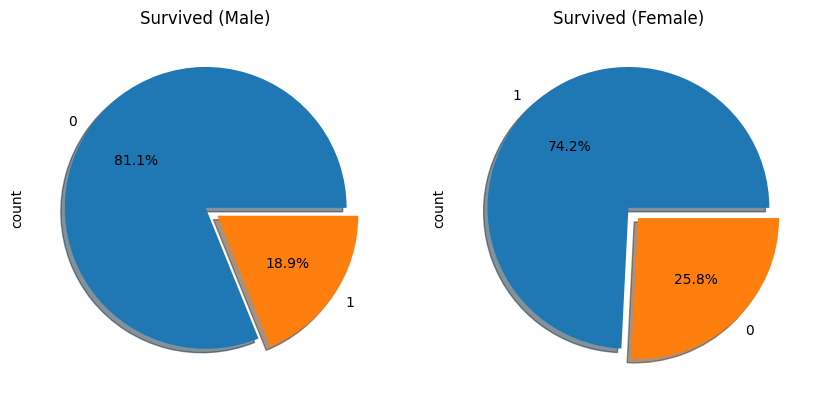

In [7]:
import matplotlib.pyplot as plt
f,ax = plt.subplots(1, 2, figsize = (10, 5))
titanic['survived'][titanic['sex'] == 'male'].value_counts().plot.pie(explode = [0,0.1], autopct = '%1.1f%%', ax = ax[0], shadow = True)
titanic['survived'][titanic['sex'] == 'female'].value_counts().plot.pie(explode = [0,0.1], autopct = '%1.1f%%', ax = ax[1], shadow = True)
ax[0].set_title('Survived (Male)')
ax[1].set_title('Survived (Female)')
plt.show()


5.3 등급별 생존자 수를 차트로 나타내기

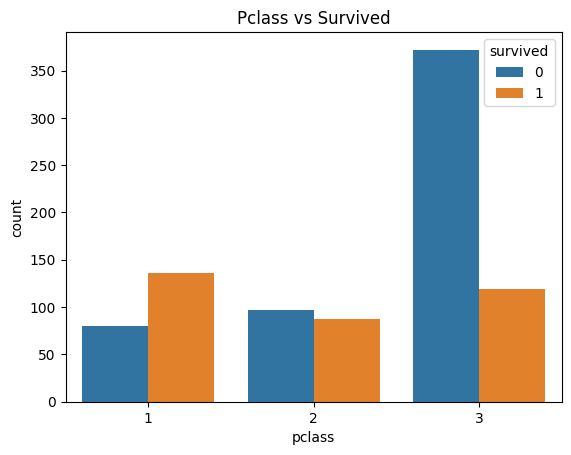

In [8]:
sns.countplot(x = 'pclass', hue = 'survived', data = titanic)
plt.title('Pclass vs Survived')
plt.show()


#6 데이터 모델링
#6.1 상관 분석을 위한 상관 계수 구하고 저장하기


In [9]:
titanic2 = titanic.select_dtypes(include=[int, float,bool])
titanic2.shape
titanic_corr = titanic2.corr(method = 'pearson')
titanic_corr
titanic_corr.to_csv('/content/titanic_corr.csv', index = False)


#6.3 특정 변수 사이의 상관 계수 구하기

In [10]:
titanic['survived'].corr(titanic['adult_male'])
titanic['survived'].corr(titanic['fare'])


np.float64(0.2573065223849625)

#7 결과 시각화
#7.1 산점도로 상관 분석 시각화하기


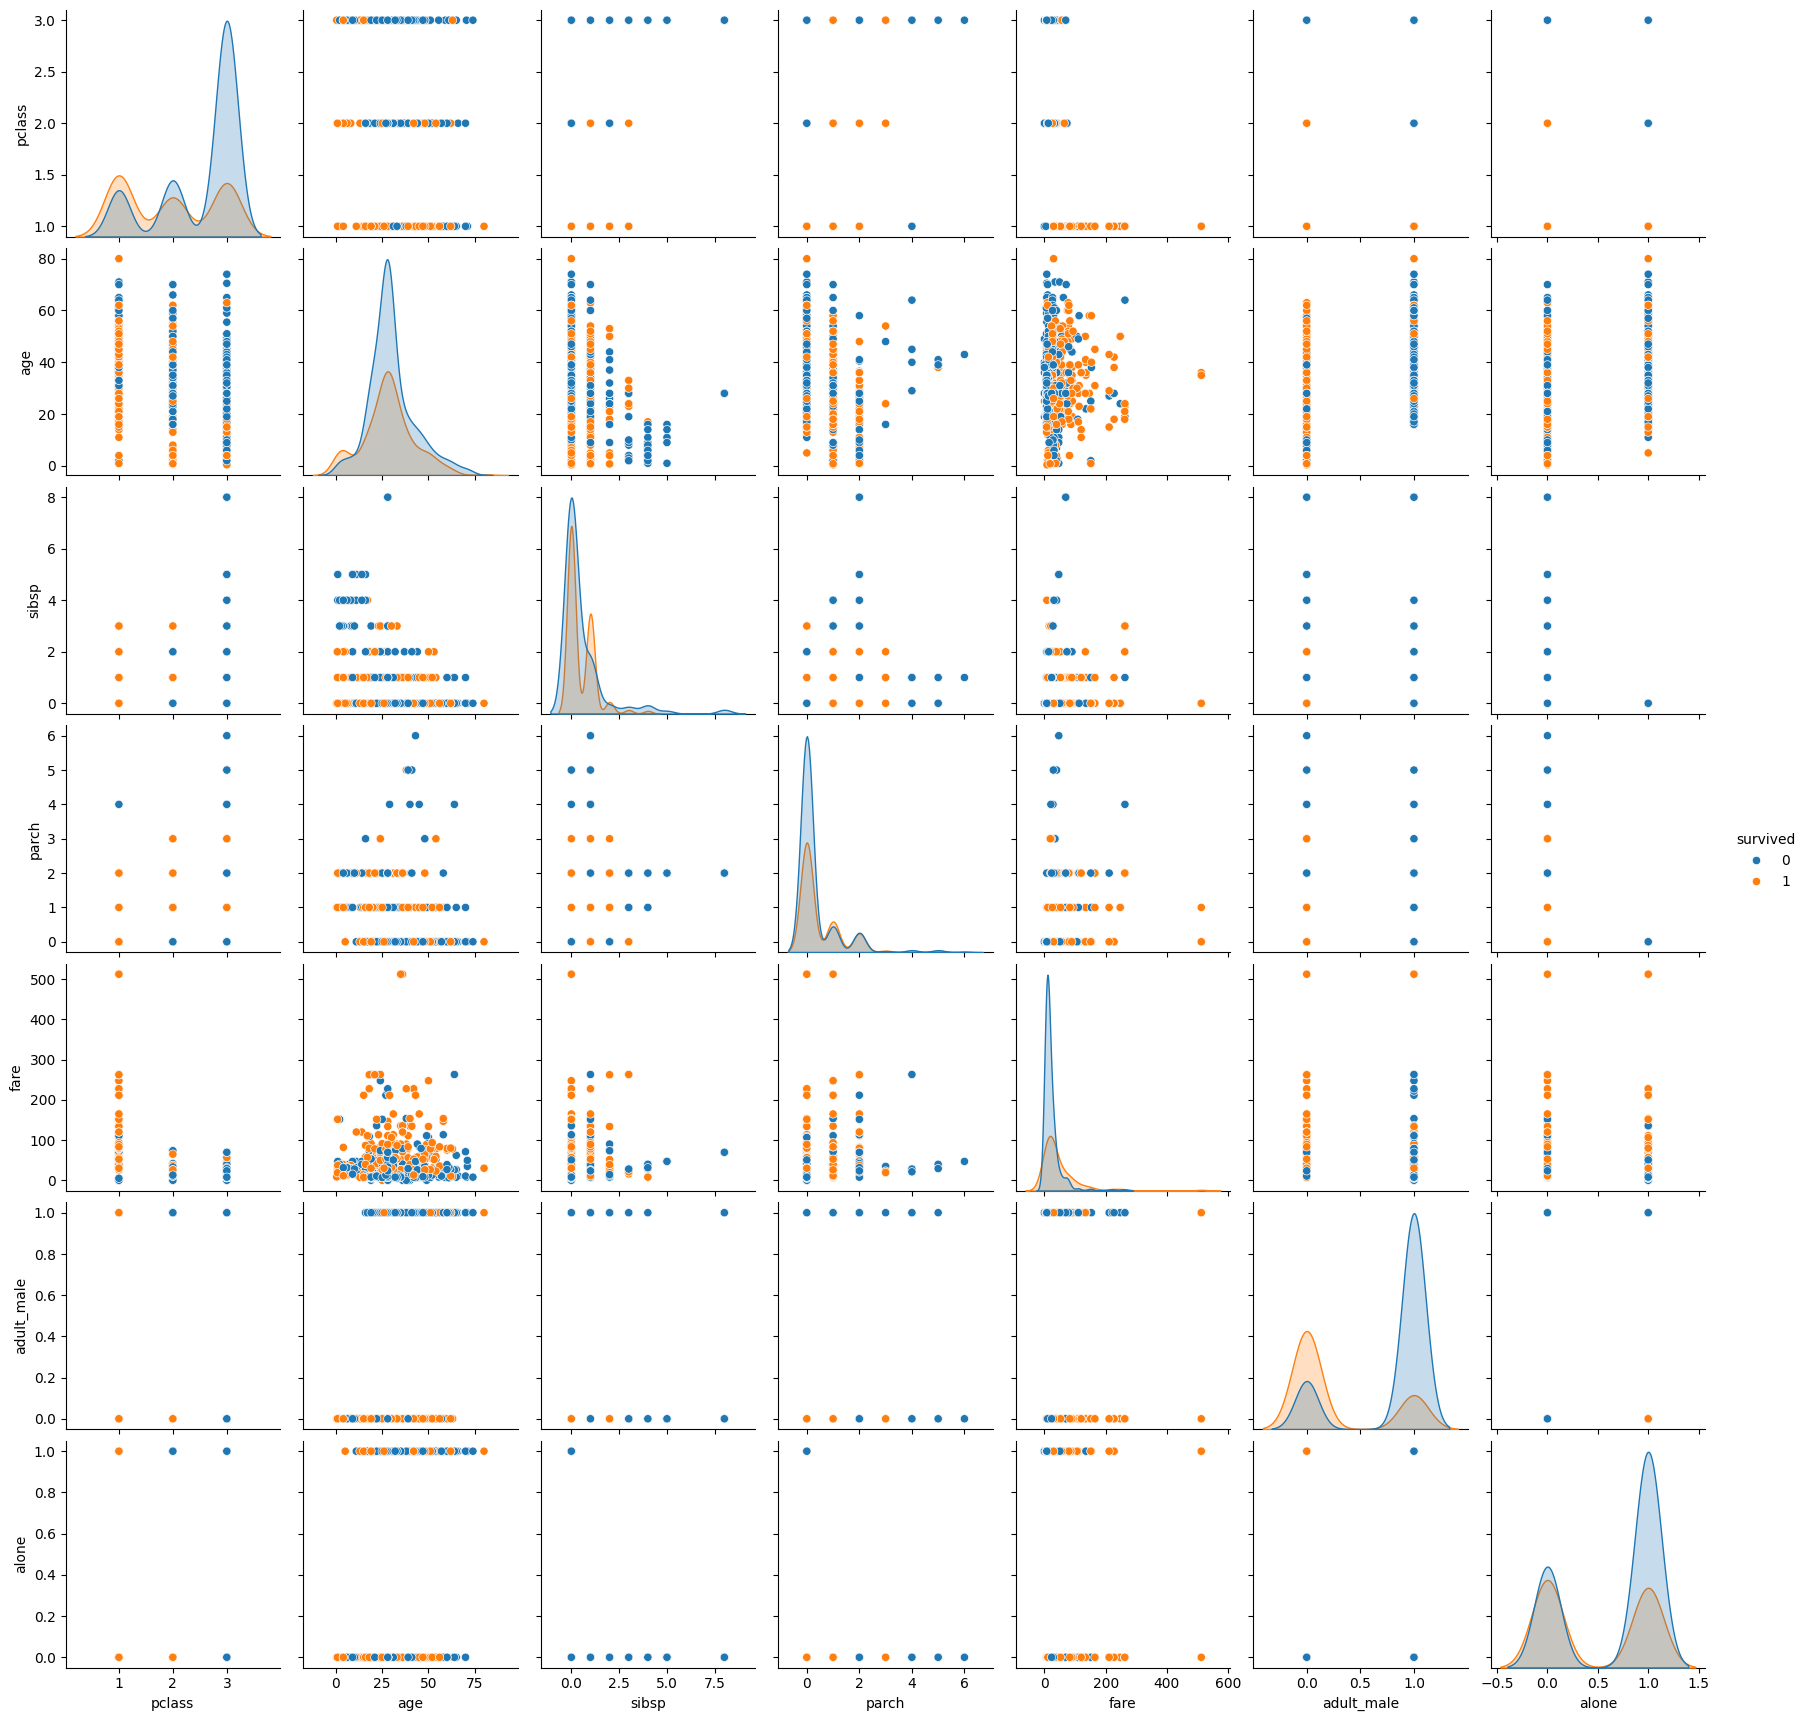

In [11]:
sns.pairplot(titanic, hue = 'survived')
plt.show()


#7.2 두 변수의 상관관계 시각화하기

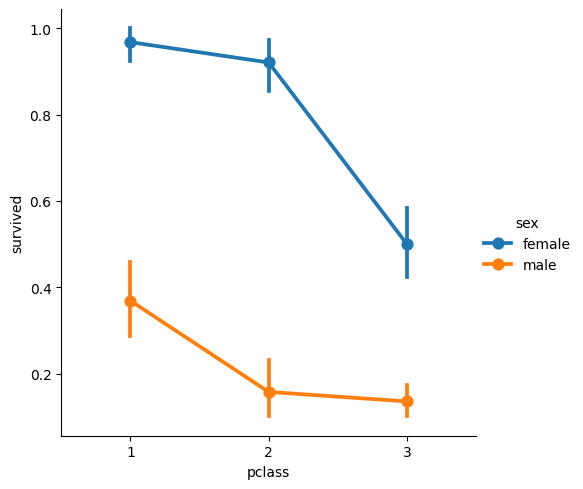

In [12]:
sns.catplot(x = 'pclass', y = 'survived', hue = 'sex', data = titanic, kind = 'point')
plt.show()


#7.3 변수 사이의 상관 계수를 히트맵으로 시각화하기

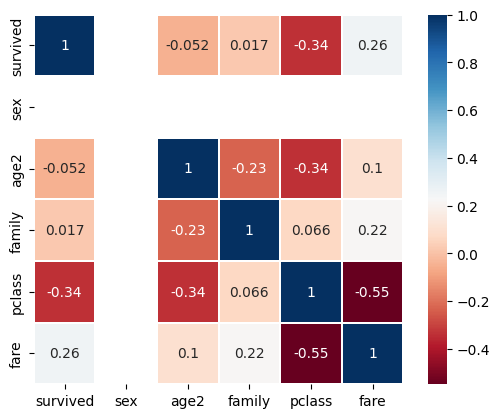

In [14]:
def category_age(x):
    if x < 10:
        return 0
    elif x < 20:
        return 1
    elif x < 30:
        return 2
    elif x < 40:
        return 3
    elif x < 50:
        return 4
    elif x < 60:
        return 5
    elif x < 70:
        return 6
    else:
        return 7


titanic['age2'] = titanic['age'].apply(category_age)
titanic['sex'] = titanic['sex'].map({'male':1, 'female':0})
titanic['family'] = titanic['sibsp'] + titanic['parch'] + 1
titanic.to_csv('/content/titanic3.csv', index = False)
heatmap_data = titanic[['survived', 'sex', 'age2', 'family', 'pclass', 'fare']]
colormap = plt.cm.RdBu
sns.heatmap(heatmap_data.astype(float).corr(), linewidths = 0.1, vmax = 1.0, square = True, cmap = colormap, linecolor = 'white', annot = True, annot_kws = {"size": 10})

plt.show()



